# Imports

In [2]:
from pathlib import Path
import re
import warnings

import esm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import ndcg_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

/Users/kevinbauer/anaconda3/envs/esm2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Paths

In [ ]:
# Paths
DATA_DIR = Path("../data")
EXPERIMENTAL_DIR = DATA_DIR / "experimental_datasets"
TOURNAMENT_DIR = DATA_DIR / "tournament"
PETASE_DIR = DATA_DIR / "PETase_zero_shot"
DLG4_DIR = DATA_DIR / "test_data"
OUTPUT_DIR = Path("esm2_zero_shot_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "esm2_t33_650M_UR50D"
SCORE_COL = "ESM2"
VARIANT_RE = re.compile(r"^([A-Z])(\d+)([A-Z])$")

# Reference WT sequences used for variant numbering in the benchmark datasets.
# Important: for UBE4B, GRB2 and PTEN, the variant positions refer to these canonical WT sequences,
# not necessarily to the per-row sequence column.
UBE4B_LONG_SEQ = "MEELSADEIRRRRLARLAGGQTSQPTTPLTSPQRENPPGPPIAASAPGPSQSLGLNVHNMTPATSPIGAAGVAHRSQSSEGVSSLSSSPSNSLETQSQSLSRSQSMDIDGVSCEKSMSQVDVDSGIENMEVDENDRREKRSLSDKEPSSGPEVSEEQALQLVCKIFRVSWKDRDRDVIFLSSLSAQFKQNPKEVFSDFKDLIGQILMEVLMMSTQTRDENPFASLTATSQPIATAARSPDRNLMLNTGSSSGTSPMFCNMGSFSTSSLSSLGASGGASNWDSYSDHFTIETCKETDMLNYLIECFDRVGIEEKKAPKMCSQPAVSQLLSNIRSQCISHTALVLQGSLTQPRSLQQPSFLVPYMLCRNLPYGFIQELVRTTHQDEEVFKQIFIPILQGLALAAKECSLESDYFKYPLMALGELCETKFGKTHPMCNLVASLPLWLPKSLSPGSGRELQRLSYLGAFFSFSVFAEDDAKVVEKYFSGPAITLENTRVVSQSLQHYLELGRQELFKILHSILLNGETREAALSYMAALVNANMKKAQMQADDRLVSTDGFMLNLLWVLQQLSTKIKLETVDPTYIFHPRCRITLPNDETRINATMEDVNERLTELYGDQPPFSEPKFPTECFFLTLHAHHLSILPSCRRYIRRLRAIRELNRTVEDLKNNESQWKDSPLATRHREMLKRCKTQLKKLVRCKACADAGLLDESFLRRCLNFYGLLIQLMLRILDPAYPDVTLPLNSEVPKVFAALPEFYVEDVAEFLFFIVQYSPQVLYEPCTQDIVMFLVVMLCNQNYIRNPYLVAKLVEVMFMTNPSVQPRTQKFFEMIENHPLSTKLLVPSLMKFYTDVEHTGATSEFYDKFTIRYHISTIFKSLWQNIAHHGTFMEEFNSGKQFVRYINMLINDTTFLLDESLESLKRIHEVQEEMKNKEQWDQLPRDQQQARQSQLAQDERVSRSYLALATETVDMFHLLTKQVQKPFLRPELGPRLAAMLNFNLQQLCGPKCRDLKVENPEKYGFEPKKLLDQLTDIYLQLDCARFAKAIADDQRSYSKELFEEVISKMRKAGIKSTIAIEKFKLLAEKVEEIVAKNARAEIDYSDAPDEFRDPLMDTLMTDPVRLPSGTVMDRSIILRHLLNSPTDPFNRQMLTESMLEPVPELKEQIQAWMREKQSSDH"

GRB2_LONG_SEQ = "MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDGFIPKNYIEMKPHPWFFGKIPRAKAEEMLSKQRHDGAFLIRESESAPGDFSLSVKFGNDVQHFKVLRDGAGKYFLWVVKFNSLNELVDYHRSTSVSRNQQIFLRDIEQVPQQPTYVQALFDFDPQEDGELGFRRGDFIHVMDNSDPNWWKGACHGQTGMFPRNYVTPVNRNV"

PTEN_LONG_SEQ = "MTAIIKEIVSRNKRRYQEDGFDLDLTYIYPNIIAMGFPAERLEGVYRNNIDDVVRFLDSKHKNHYKIYNLCAERHYDTAKFNCRVAQYPFEDHNPPQLELIKPFCEDLDQWLSEDDNHVAAIHCKAGKGRTGVMICAYLLHRGKFLKAQEALDFYGEVRTRDKKGVTIPSQRRYVYYYSYLLKNHLDYRPVALLFHKMMFETIPMFSGGTCNPQFVVCQLKVKIYSSNSGPTRREDKFMYFEFPQPLPVCGDIKVEFFHKQNKMLKKDKMFHFWVNTFFIPGPEETSEKVENGSLCDQEIDSICSIERADNDKEYLVLTLTKNDLDKANKDKANRYFSPNFKVKLYFTKTVEEPSNPEASSSTSVTPDVSDNEPDHYRYSDTTDSDPENEPFDEDQHTQITKV"

DATASET_CONFIG = {
    "UBE4B": {
        "path": EXPERIMENTAL_DIR / "ube4b_with_full_sequence.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "wt_sequence": UBE4B_LONG_SEQ,
    },
    "GRB2": {
        "path": EXPERIMENTAL_DIR / "grb2_with_full_sequence.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "wt_sequence": GRB2_LONG_SEQ,
    },
    "PTEN_activity": {
        "path": EXPERIMENTAL_DIR / "pten-activity_with_full_sequence.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "wt_sequence": PTEN_LONG_SEQ,
    },
    "PTEN_abundance": {
        "path": EXPERIMENTAL_DIR / "pten-abundance_with_full_sequence.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
        "wt_sequence": PTEN_LONG_SEQ,
    },
    "Alpha-Amylase": {
        "path": TOURNAMENT_DIR / "Alpha-Amylase with WT(in silico_ Zero Shot).csv",
        "sep": "\t",
        "variant_col": "mutant",
        "sequence_col": "mutated_sequence",
        "target_cols": ["expression", "thermostability", "specific activity"],
        "position_base": 1,
        "reconstruct_wt": True,
    },
    "PETase": {
        "path": PETASE_DIR / "petase_zero_shot_full_dataset.csv",
        "sep": ",",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": [],
        "position_base": 1,
    },
    "DLG4_abundance": {
        "path": DLG4_DIR / "dlg4-2022-abundance.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
    },
    "DLG4_binding": {
        "path": DLG4_DIR / "dlg4-2022-binding.tsv",
        "sep": "\t",
        "variant_col": "variant",
        "sequence_col": "sequence",
        "target_cols": ["score"],
        "position_base": 0,
    }
}

## ESM-2 Model

In [4]:
def load_esm2_model(model_name: str = MODEL_NAME, device: str | None = None):
    """Load ESM-2 model, alphabet and batch converter."""
    model, alphabet = getattr(esm.pretrained, model_name)()
    model.eval()

    if device is None:
        if torch.cuda.is_available():
            device = "cuda"
        elif torch.backends.mps.is_available():
            device = "mps"
        else:
            device = "cpu"

    model = model.to(device)
    batch_converter = alphabet.get_batch_converter()
    print(f"Loaded {model_name} on {device}")
    return model, alphabet, batch_converter, device


def parse_variant(variant: str):
    """Parse variants such as A123B into wild-type AA, numeric position, mutant AA."""
    match = VARIANT_RE.match(str(variant).strip().upper())
    if match is None:
        return None
    wt_aa, pos, mut_aa = match.groups()
    return wt_aa, int(pos), mut_aa


def to_sequence_position_1based(variant_position: int, position_base: int) -> int:
    """Convert variant numbering to 1-based sequence numbering."""
    if position_base == 0:
        return variant_position + 1
    if position_base == 1:
        return variant_position
    raise ValueError("position_base must be either 0 or 1")


def reconstruct_wild_type_sequence(mutated_sequence: str, position_1based: int, wt_aa: str) -> str:
    """Reconstruct WT sequence if only the mutated sequence is available."""
    seq = list(str(mutated_sequence))
    seq[position_1based - 1] = wt_aa
    return "".join(seq)

In [5]:
def esm2_log_odds(
    sequence: str,
    position_1based: int,
    wt_aa: str,
    mut_aa: str,
    model,
    alphabet,
    batch_converter,
    device: str,
) -> float:
    """Compute log P(mutant residue) - log P(wild-type residue) at one masked position."""
    _, _, tokens = batch_converter([("seq", sequence)])
    tokens = tokens.to(device)

    masked_tokens = tokens.clone()
    masked_tokens[0, position_1based] = alphabet.mask_idx

    with torch.no_grad():
        logits = model(masked_tokens, repr_layers=[], return_contacts=False)["logits"][0, position_1based]

    log_probs = torch.log_softmax(logits, dim=-1)
    wt_log_prob = log_probs[alphabet.tok_to_idx[wt_aa]].item()
    mut_log_prob = log_probs[alphabet.tok_to_idx[mut_aa]].item()

    return float(mut_log_prob - wt_log_prob)


def add_esm2_scores(
    df: pd.DataFrame,
    *,
    variant_col: str = "variant",
    sequence_col: str = "sequence",
    position_base: int = 1,
    wt_sequence: str | None = None,
    reconstruct_wt: bool = False,
    model=None,
    alphabet=None,
    batch_converter=None,
    device: str | None = None,
    score_col: str = SCORE_COL,
) -> pd.DataFrame:
    """Add ESM-2 zero-shot log-odds scores to a dataframe.

    If `wt_sequence` is given, this fixed reference sequence is used for scoring.
    This is necessary for datasets where variant numbering refers to a canonical WT
    sequence rather than to the per-row `sequence` column.
    """
    df = df.copy()
    df[score_col] = np.nan

    skipped = {
        "invalid_variant": 0,
        "position_out_of_range": 0,
        "wt_mismatch": 0,
        "unknown_aa": 0,
    }

    for idx in tqdm(df.index, total=len(df)):
        parsed = parse_variant(df.at[idx, variant_col])

        if parsed is None:
            skipped["invalid_variant"] += 1
            continue

        wt_aa, variant_pos, mut_aa = parsed
        position_1based = to_sequence_position_1based(variant_pos, position_base)

        if wt_sequence is not None:
            sequence = wt_sequence
        else:
            sequence = str(df.at[idx, sequence_col])

        if reconstruct_wt:
            sequence = reconstruct_wild_type_sequence(sequence, position_1based, wt_aa)

        if position_1based < 1 or position_1based > len(sequence):
            skipped["position_out_of_range"] += 1
            continue

        if sequence[position_1based - 1] != wt_aa:
            skipped["wt_mismatch"] += 1
            continue

        if wt_aa not in alphabet.tok_to_idx or mut_aa not in alphabet.tok_to_idx:
            skipped["unknown_aa"] += 1
            continue

        df.at[idx, score_col] = esm2_log_odds(
            sequence=sequence,
            position_1based=position_1based,
            wt_aa=wt_aa,
            mut_aa=mut_aa,
            model=model,
            alphabet=alphabet,
            batch_converter=batch_converter,
            device=device,
        )

    skipped = {k: v for k, v in skipped.items() if v > 0}
    if skipped:
        print("Skipped rows:", skipped)

    return df

# Correlation Metrics

In [6]:
def ndcg_at_fraction(pred, true, frac: float = 0.10) -> float:
    """NDCG at top fraction. Experimental values are shifted to be non-negative."""
    pred = pd.to_numeric(pd.Series(pred), errors="coerce").to_numpy(dtype=float)
    true = pd.to_numeric(pd.Series(true), errors="coerce").to_numpy(dtype=float)

    mask = np.isfinite(pred) & np.isfinite(true)
    pred, true = pred[mask], true[mask]

    if len(true) < 3:
        return np.nan

    k = max(1, min(int(np.ceil(frac * len(true))), len(true)))
    true_shifted = true - np.min(true)

    if np.max(true_shifted) == 0:
        return np.nan

    return float(ndcg_score(true_shifted.reshape(1, -1), pred.reshape(1, -1), k=k))


def evaluate_scores(df: pd.DataFrame, target_col: str, score_col: str = SCORE_COL) -> dict:
    x = pd.to_numeric(df[target_col], errors="coerce")
    y = pd.to_numeric(df[score_col], errors="coerce")
    mask = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 3:
        return {"n": int(mask.sum()), "pearson": np.nan, "spearman": np.nan, "ndcg@10%": np.nan}

    x_values = x[mask].to_numpy(float)
    y_values = y[mask].to_numpy(float)

    return {
        "n": int(mask.sum()),
        "pearson": pearsonr(x_values, y_values).statistic,
        "spearman": spearmanr(x_values, y_values).correlation,
        "ndcg@10%": ndcg_at_fraction(y_values, x_values, frac=0.10),
    }


def plot_scores(df: pd.DataFrame, dataset_name: str, target_col: str, score_col: str = SCORE_COL):
    x = pd.to_numeric(df[target_col], errors="coerce")
    y = pd.to_numeric(df[score_col], errors="coerce")
    mask = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)

    if mask.sum() < 3:
        print(f"Not enough data points for {dataset_name} / {target_col}")
        return

    metrics = evaluate_scores(df, target_col=target_col, score_col=score_col)

    plt.figure(figsize=(7, 5))
    plt.scatter(x[mask], y[mask], alpha=0.5)
    plt.xlabel(target_col)
    plt.ylabel(score_col)
    plt.title(f"{dataset_name}: {score_col} vs. {target_col}")
    plt.text(
        0.05,
        0.90,
        f"Spearman = {metrics['spearman']:.3f}\nNDCG@10% = {metrics['ndcg@10%']:.3f}",
        transform=plt.gca().transAxes,
    )
    plt.tight_layout()
    plt.show()

# Load all datasets and model

In [7]:
def load_dataset(dataset_name: str) -> tuple[pd.DataFrame, dict]:
    config = DATASET_CONFIG[dataset_name]
    df = pd.read_csv(config["path"], sep=config["sep"])

    if config["variant_col"] != "variant" and config["variant_col"] in df.columns:
        df = df.rename(columns={config["variant_col"]: "variant"})
        config = {**config, "variant_col": "variant"}

    if "num_mutations" in df.columns:
        df = df.loc[df["num_mutations"] == 1].copy()

    return df, config


model, alphabet, batch_converter, device = load_esm2_model(MODEL_NAME)

Loaded esm2_t33_650M_UR50D on mps



===== DLG4_abundance =====
Rows after filtering single mutations: 1280


100%|██████████| 1280/1280 [01:03<00:00, 20.20it/s]


Saved: esm2_zero_shot_outputs/DLG4_abundance_with_esm2.csv
score: {'n': 1280, 'pearson': np.float64(0.5276324565789169), 'spearman': np.float64(0.5182696802431194), 'ndcg@10%': 0.8664101971418969}


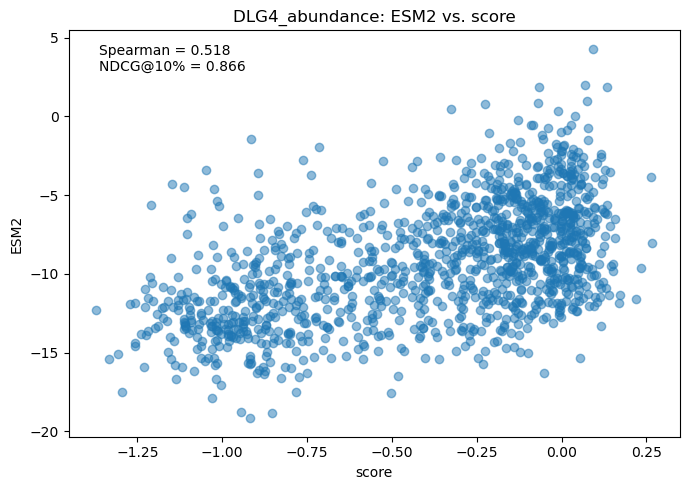


===== DLG4_binding =====
Rows after filtering single mutations: 1441


100%|██████████| 1441/1441 [01:13<00:00, 19.62it/s]

Saved: esm2_zero_shot_outputs/DLG4_binding_with_esm2.csv
score: {'n': 1441, 'pearson': np.float64(0.6472592983907385), 'spearman': np.float64(0.6509886404912781), 'ndcg@10%': 0.8936315743470263}


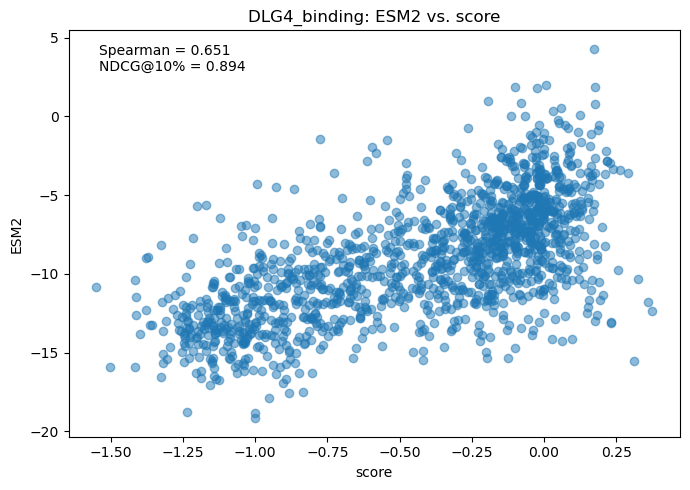

,dataset,target,n,pearson,spearman,ndcg@10%
0,DLG4_abundance,score,1280,0.528,0.518,0.866
1,DLG4_binding,score,1441,0.647,0.651,0.894


In [ ]:
# Run ESM-2 zero-shot scoring for the benchmark datasets
benchmark_names = ["UBE4B", "GRB2", "PTEN_activity", "PTEN_abundance", "DLG4_abundance", "DLG4_binding"]
scored_datasets = {}
benchmark_metrics = []

for dataset_name in benchmark_names:
    print(f"\n===== {dataset_name} =====")
    df, config = load_dataset(dataset_name)
    print(f"Rows after filtering single mutations: {len(df)}")

    df_scored = add_esm2_scores(
        df,
        variant_col=config["variant_col"],
        sequence_col=config["sequence_col"],
        position_base=config["position_base"],
        wt_sequence=config.get("wt_sequence"),
        reconstruct_wt=config.get("reconstruct_wt", False),
        model=model,
        alphabet=alphabet,
        batch_converter=batch_converter,
        device=device,
    )

    out_path = OUTPUT_DIR / f"{dataset_name}_with_esm2.csv"
    df_scored.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

    for target_col in config["target_cols"]:
        metrics = evaluate_scores(df_scored, target_col=target_col)
        benchmark_metrics.append({"dataset": dataset_name, "target": target_col, **metrics})
        print(f"{target_col}: {metrics}")
        plot_scores(df_scored, dataset_name, target_col)

    scored_datasets[dataset_name] = df_scored

benchmark_metrics_df = pd.DataFrame(benchmark_metrics)
display(benchmark_metrics_df.round(3))


===== Alpha-Amylase =====
Rows: 8075


100%|██████████| 8075/8075 [21:56<00:00,  6.14it/s]


Saved: esm2_zero_shot_outputs/Alpha-Amylase_with_esm2.csv
expression: {'n': 7575, 'pearson': np.float64(0.5313392024810187), 'spearman': np.float64(0.5413892692328974), 'ndcg@10%': 0.6927545976870494}


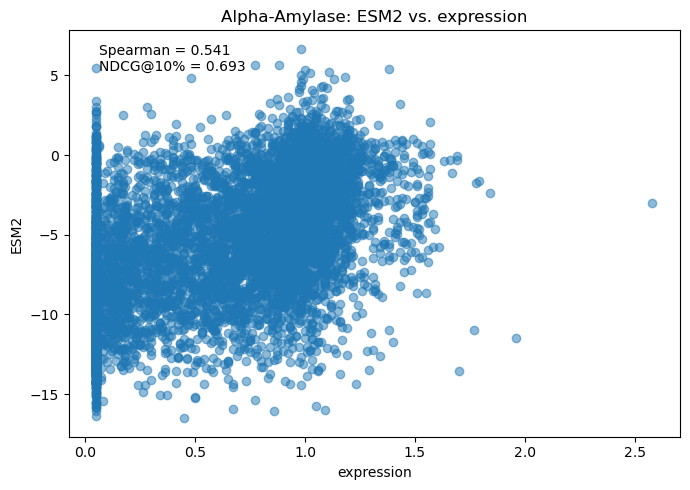

thermostability: {'n': 7574, 'pearson': np.float64(0.10579752773553434), 'spearman': np.float64(0.3895859657980113), 'ndcg@10%': 0.3038785161349726}


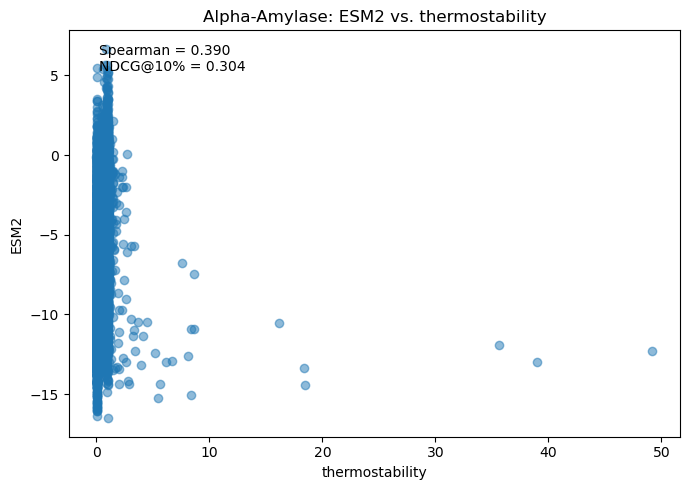

specific activity: {'n': 7575, 'pearson': np.float64(0.3421495071341949), 'spearman': np.float64(0.3874851275308572), 'ndcg@10%': 0.43656193292019324}


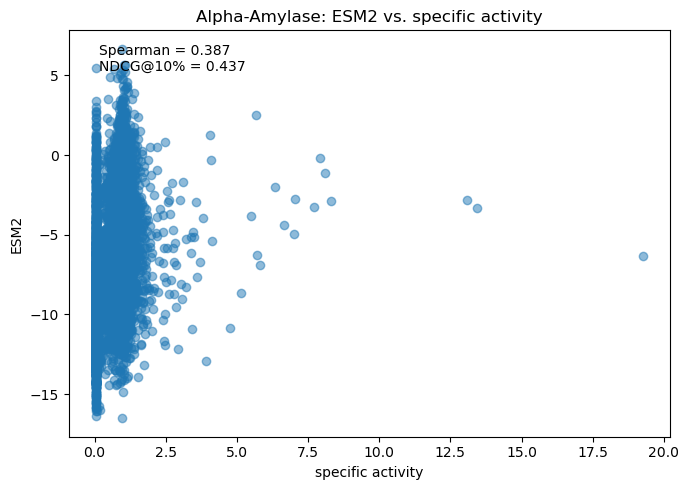

,dataset,target,n,pearson,spearman,ndcg@10%
0,Alpha-Amylase,expression,7575,0.531,0.541,0.693
1,Alpha-Amylase,thermostability,7574,0.106,0.390,0.304
2,Alpha-Amylase,specific activity,7575,0.342,0.387,0.437


In [36]:
# Run ESM-2 zero-shot scoring for Alpha-Amylase
DATASET_NAME = "Alpha-Amylase"
print(f"\n===== {DATASET_NAME} =====")

df_alpha, config = load_dataset(DATASET_NAME)
print(f"Rows: {len(df_alpha)}")

df_alpha_scored = add_esm2_scores(
    df_alpha,
    variant_col=config["variant_col"],
    sequence_col=config["sequence_col"],
    position_base=config["position_base"],
    reconstruct_wt=config.get("reconstruct_wt", False),
    model=model,
    alphabet=alphabet,
    batch_converter=batch_converter,
    device=device,
)

out_path = OUTPUT_DIR / f"{DATASET_NAME}_with_esm2.csv"
df_alpha_scored.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

alpha_metrics = []
for target_col in config["target_cols"]:
    metrics = evaluate_scores(df_alpha_scored, target_col=target_col)
    alpha_metrics.append({"dataset": DATASET_NAME, "target": target_col, **metrics})
    print(f"{target_col}: {metrics}")
    plot_scores(df_alpha_scored, DATASET_NAME, target_col)

alpha_metrics_df = pd.DataFrame(alpha_metrics)
display(alpha_metrics_df.round(3))


===== PETase =====
Rows after filtering single mutations: 4674


100%|██████████| 4674/4674 [08:23<00:00,  9.28it/s]


Saved: esm2_zero_shot_outputs/PETase_with_esm2.csv


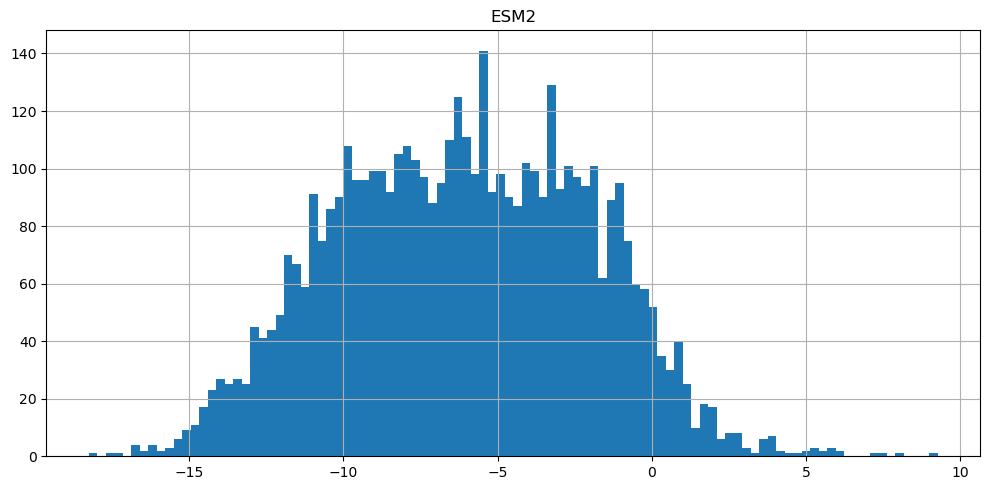

,ESM2
count,4674.000000
mean,-6.136040
std,4.088448
min,-18.254733
25%,-9.294683
50%,-6.122168
75%,-2.994295
max,9.263345


In [39]:
# Run ESM-2 zero-shot scoring for PETase
DATASET_NAME = "PETase"
print(f"\n===== {DATASET_NAME} =====")

df_petase, config = load_dataset(DATASET_NAME)
print(f"Rows after filtering single mutations: {len(df_petase)}")

df_petase_scored = add_esm2_scores(
    df_petase,
    variant_col=config["variant_col"],
    sequence_col=config["sequence_col"],
    position_base=config["position_base"],
    reconstruct_wt=config.get("reconstruct_wt", False),
    model=model,
    alphabet=alphabet,
    batch_converter=batch_converter,
    device=device,
)

out_path = OUTPUT_DIR / "PETase_with_esm2.csv"
df_petase_scored.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

df_petase_scored[[SCORE_COL]].hist(bins=100, figsize=(10, 5))
plt.tight_layout()
plt.show()

display(df_petase_scored[[SCORE_COL]].describe())

In [40]:
# Optional: save separate PETase files for WT_1, WT_2 and WT_3
if "wt_index" in df_petase_scored.columns:
    wt_output_dir = OUTPUT_DIR / "final_data"
    wt_output_dir.mkdir(parents=True, exist_ok=True)

    for wt_index, wt_name in {0: "WT_1", 1: "WT_2", 2: "WT_3"}.items():
        wt_df = df_petase_scored.loc[df_petase_scored["wt_index"] == wt_index].copy()
        out_path = wt_output_dir / f"{wt_name}.csv"
        wt_df.to_csv(out_path, index=False)
        print(f"Saved {wt_name}: {out_path} ({len(wt_df)} rows)")
else:
    print("Column 'wt_index' not found. Skipping WT-specific exports.")

Saved WT_1: esm2_zero_shot_outputs/final_data/WT_1.csv (1558 rows)
Saved WT_2: esm2_zero_shot_outputs/final_data/WT_2.csv (1558 rows)
Saved WT_3: esm2_zero_shot_outputs/final_data/WT_3.csv (1558 rows)


In [44]:
def add_ranking(
    df: pd.DataFrame,
    score_col: str = SCORE_COL,
    rank_col: str = "ESM2_rank",
    rank_norm_col: str = "ESM2_rank_norm",
    higher_is_better: bool = True,
    method: str = "average",
) -> pd.DataFrame:
    """Add rank and normalized rank. Normalized rank: 0 = best, 1 = worst."""
    df = df.copy()
    scores = pd.to_numeric(df[score_col], errors="coerce")
    mask = scores.notna() & np.isfinite(scores)
    n = int(mask.sum())

    df[rank_col] = np.nan
    df[rank_norm_col] = np.nan

    if n == 0:
        return df

    df.loc[mask, rank_col] = scores[mask].rank(
        ascending=not higher_is_better,
        method=method,
    )
    df.loc[mask, rank_norm_col] = (
        0.0 if n == 1 else (df.loc[mask, rank_col] - 1) / (n - 1)
    )

    return df


# Add rankings to all scored CSV files directly in OUTPUT_DIR
for path in sorted(OUTPUT_DIR.glob("*_with_esm2.csv")):
    df = pd.read_csv(path)

    if SCORE_COL not in df.columns:
        print(f"Skipping {path.name}: no {SCORE_COL} column")
        continue

    df_ranked = add_ranking(df, score_col=SCORE_COL)
    out_path = path.with_name(path.stem + "_ranked.csv")
    df_ranked.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")


# Add rankings to PETase WT-specific files
wt_output_dir = OUTPUT_DIR / "final_data"

if wt_output_dir.exists():
    for path in sorted(wt_output_dir.glob("WT_*.csv")):
        df = pd.read_csv(path)

        if SCORE_COL not in df.columns:
            print(f"Skipping {path.name}: no {SCORE_COL} column")
            continue

        df_ranked = add_ranking(df, score_col=SCORE_COL)
        out_path = path.with_name(path.stem + "_ranked.csv")
        df_ranked.to_csv(out_path, index=False)
        print(f"Saved: {out_path}")
else:
    print("No final_data folder found. Skipping WT-specific ranking files.")

Saved: esm2_zero_shot_outputs/Alpha-Amylase_with_esm2_ranked.csv
Saved: esm2_zero_shot_outputs/GRB2_with_esm2_ranked.csv
Saved: esm2_zero_shot_outputs/PETase_with_esm2_ranked.csv
Saved: esm2_zero_shot_outputs/PTEN_abundance_with_esm2_ranked.csv
Saved: esm2_zero_shot_outputs/PTEN_activity_with_esm2_ranked.csv
Saved: esm2_zero_shot_outputs/UBE4B_with_esm2_ranked.csv
Saved: esm2_zero_shot_outputs/final_data/WT_1_ranked.csv
Saved: esm2_zero_shot_outputs/final_data/WT_1_ranked_ranked.csv
Saved: esm2_zero_shot_outputs/final_data/WT_2_ranked.csv
Saved: esm2_zero_shot_outputs/final_data/WT_2_ranked_ranked.csv
Saved: esm2_zero_shot_outputs/final_data/WT_3_ranked.csv
Saved: esm2_zero_shot_outputs/final_data/WT_3_ranked_ranked.csv
